# Explorative Datenanalyse – Santander Customer Transaction Prediction

## Einführung in den Datensatz

Dieses Notebook dokumentiert den ersten EDA-Schritt: Herkunft, Aufbau, Größe, Datentypen,
Spaltennamen und fehlende Werte des Santander-Datensatzes. Die Berechnungen werden aus der
lokal gespeicherten CSV-Datei erzeugt, damit die Ergebnisse reproduzierbar bleiben.

**Quelle:** OpenML-Datensatz `45566`  
**Lokale Datei:** `../data/santander_customer_transaction_prediction.csv`  
**Aufgabe:** Vorhersage, ob eine Person eine Transaktion durchführen wird.

## 1. Datenquelle und methodische Hinweise

Der Datensatz stammt aus der Kaggle Competition **Santander Customer Transaction Prediction**
aus dem Jahr 2019 und wurde über OpenML bezogen. Die Rohdaten werden bewusst nicht verändert.
Die Zielvariable wird beim Download als zusätzliche Spalte `target` gespeichert. Alle folgenden
Kennzahlen beziehen sich auf diese lokale CSV-Repräsentation.

> Die Interpretation der Variablen erfolgt erst nach der technischen Bestandsaufnahme. Die
> Spalten `var_0`, `var_1`, ... sind anonymisierte Merkmale; aus ihren Namen lässt sich keine
> fachliche Bedeutung ableiten.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
from IPython.display import display

DATA_PATH = Path("../data/santander_customer_transaction_prediction.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Datensatz nicht gefunden: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Datei: {DATA_PATH.resolve()}")
print(f"pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Python: {sys.version.split()[0]}")

Datei: C:\Users\Cypsa\Desktop\UNI\UNI JLU DS\ADA_Project\Cyp\data\santander_customer_transaction_prediction.csv
pandas: 2.2.3
NumPy: 2.0.0
Python: 3.12.3


## 2. Form und Größe des Datensatzes

Zuerst werden die Anzahl der Beobachtungen (Rows), Variablen (Columns), der belegte
Speicherbedarf und die durchschnittliche Zeilenbreite bestimmt.

In [2]:
n_rows, n_cols = df.shape
memory_bytes = df.memory_usage(index=True, deep=True).sum()
size_summary = pd.Series({
    "Rows": n_rows,
    "Columns": n_cols,
    "Speicherbedarf im DataFrame (MiB)": memory_bytes / 1024**2,
    "CSV-Dateigröße (MiB)": DATA_PATH.stat().st_size / 1024**2,
    "Durchschnittlicher Speicherbedarf je Row (KiB)": memory_bytes / n_rows / 1024,
}).round(3)
display(size_summary.to_frame("Wert"))

,Wert
Rows,200000.000
Columns,201.000
Speicherbedarf im DataFrame (MiB),305.367
CSV-Dateigröße (MiB),292.016
Durchschnittlicher Speicherbedarf je Row (KiB),1.563


## 3. Spaltennamen und Datentypen

Die Spaltennamen werden vollständig ausgegeben. Zusätzlich wird geprüft, wie viele Spalten
je Datentyp vorkommen. Das ist wichtig für die spätere Wahl von Speicherformaten,
Vorverarbeitung und Machine-Learning-Pipelines.

In [3]:
column_overview = pd.DataFrame({
    "Spaltenname": df.columns,
    "Datentyp": df.dtypes.astype(str).to_numpy(),
    "Anzahl eindeutiger Werte": [df[col].nunique(dropna=False) for col in df.columns],
    "Fehlende Werte": [df[col].isna().sum() for col in df.columns],
})

print(f"Anzahl Spaltennamen: {len(df.columns)}")
print("Vollständige Spaltennamen:")
for number, name in enumerate(df.columns, start=1):
    print(f"{number:>3}: {name}")

print("\nAnzahl Spalten je Datentyp:")
display(df.dtypes.astype(str).value_counts().rename_axis("Datentyp").to_frame("Anzahl Spalten"))

print("Spaltenübersicht:")
display(column_overview)

Anzahl Spaltennamen: 201
Vollständige Spaltennamen:
  1: var_0
  2: var_1
  3: var_2
  4: var_3
  5: var_4
  6: var_5
  7: var_6
  8: var_7
  9: var_8
 10: var_9
 11: var_10
 12: var_11
 13: var_12
 14: var_13
 15: var_14
 16: var_15
 17: var_16
 18: var_17
 19: var_18
 20: var_19
 21: var_20
 22: var_21
 23: var_22
 24: var_23
 25: var_24
 26: var_25
 27: var_26
 28: var_27
 29: var_28
 30: var_29
 31: var_30
 32: var_31
 33: var_32
 34: var_33
 35: var_34
 36: var_35
 37: var_36
 38: var_37
 39: var_38
 40: var_39
 41: var_40
 42: var_41
 43: var_42
 44: var_43
 45: var_44
 46: var_45
 47: var_46
 48: var_47
 49: var_48
 50: var_49
 51: var_50
 52: var_51
 53: var_52
 54: var_53
 55: var_54
 56: var_55
 57: var_56
 58: var_57
 59: var_58
 60: var_59
 61: var_60
 62: var_61
 63: var_62
 64: var_63
 65: var_64
 66: var_65
 67: var_66
 68: var_67
 69: var_68
 70: var_69
 71: var_70
 72: var_71
 73: var_72
 74: var_73
 75: var_74
 76: var_75
 77: var_76
 78: var_77
 79: var_78
 80: var_7

,Anzahl Spalten
Datentyp,
float64,200
bool,1


Spaltenübersicht:


,Spaltenname,Datentyp,Anzahl eindeutiger Werte,Fehlende Werte
0,var_0,float64,94672,0
1,var_1,float64,108932,0
2,var_2,float64,86555,0
3,var_3,float64,74597,0
4,var_4,float64,63515,0
...,...,...,...,...
196,var_196,float64,125560,0
197,var_197,float64,40537,0
198,var_198,float64,94153,0
199,var_199,float64,149430,0


## 4. Fehlende Werte

Fehlende Werte werden sowohl insgesamt als auch spaltenweise gezählt. Zusätzlich wird
ermittelt, wie viele Rows mindestens einen fehlenden Wert enthalten. Eine fehlende Zelle
wird dabei nicht mit einem fehlenden Datensatz gleichgesetzt: Entscheidend sind sowohl die
Anzahl der betroffenen Zellen als auch die betroffenen Zeilen.

In [4]:
missing_by_column = (
    df.isna().sum()
      .rename("Anzahl fehlender Werte")
      .to_frame()
      .assign(**{"Anteil fehlender Werte (%)": lambda x: (x["Anzahl fehlender Werte"] / len(df) * 100).round(4)})
      .sort_values("Anzahl fehlender Werte", ascending=False)
)
total_missing_cells = int(df.isna().sum().sum())
rows_with_missing = int(df.isna().any(axis=1).sum())
complete_rows = int(df.notna().all(axis=1).sum())

missing_summary = pd.Series({
    "Fehlende Zellen insgesamt": total_missing_cells,
    "Rows mit mindestens einem fehlenden Wert": rows_with_missing,
    "Rows ohne fehlende Werte": complete_rows,
    "Spalten mit mindestens einem fehlenden Wert": int((missing_by_column["Anzahl fehlender Werte"] > 0).sum()),
})

display(missing_summary.to_frame("Wert"))
print("Spalten mit fehlenden Werten:")
display(missing_by_column[missing_by_column["Anzahl fehlender Werte"] > 0])

,Wert
Fehlende Zellen insgesamt,0
Rows mit mindestens einem fehlenden Wert,0
Rows ohne fehlende Werte,200000
Spalten mit mindestens einem fehlenden Wert,0


Spalten mit fehlenden Werten:


,Anzahl fehlender Werte,Anteil fehlender Werte (%)


## 5. Zielvariable und erste Plausibilitätsprüfung

Die beim Download ergänzte Spalte `target` wird separat betrachtet. Die Klassenverteilung
ist für die spätere Wahl der Evaluationsmetriken relevant. In diesem Einführungsschritt
werden noch keine Werte bereinigt, transformiert oder für Modelle verwendet.

In [5]:
TARGET = "target"
if TARGET not in df.columns:
    raise KeyError(f"Erwartete Zielvariable fehlt: {TARGET}")

print("Zielvariable:", TARGET)
print("Zielvariable-Datentyp:", df[TARGET].dtype)
display(df[TARGET].value_counts(dropna=False).rename_axis(TARGET).to_frame("Anzahl").assign(**{"Anteil (%)": lambda x: (x["Anzahl"] / len(df) * 100).round(3)}))

print("Erste fünf Rows:")
display(df.head())
print("Letzte fünf Rows:")
display(df.tail())

Zielvariable: target
Zielvariable-Datentyp: bool


,Anzahl,Anteil (%)
target,,
False,179902,89.951
True,20098,10.049


Erste fünf Rows:


,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,...,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199,target
0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,-4.9200,5.7470,...,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914,False
1,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,3.1468,8.0851,...,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518,False
2,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,-4.9193,5.9525,...,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965,False
3,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,-5.8609,8.2450,...,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996,False
4,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,6.2654,7.6784,...,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104,False


Letzte fünf Rows:


,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,...,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199,target
199995,11.4880,-0.4956,8.2622,3.5142,10.3404,11.6081,5.6709,15.1516,-0.6209,5.6669,...,13.2305,3.9901,0.9388,18.0249,-1.7939,2.1661,8.5326,16.6660,-17.8661,False
199996,4.9149,-2.4484,16.7052,6.6345,8.3096,-10.5628,5.8802,21.5940,-3.6797,6.0019,...,4.6549,0.6998,1.8341,22.2717,1.7337,-2.1651,6.7419,15.9054,0.3388,False
199997,11.2232,-5.0518,10.5127,5.6456,9.3410,-5.4086,4.5555,21.5571,0.1202,6.1629,...,5.4414,3.1032,4.8793,23.5311,-1.5736,1.2832,8.7155,13.8329,4.1995,False
199998,9.7148,-8.6098,13.6104,5.7930,12.5173,0.5339,6.0479,17.0152,-2.1926,8.7542,...,8.6587,2.7337,11.1178,20.4158,-0.0786,6.7980,10.0342,15.5289,-13.9001,False
199999,10.8762,-5.7105,12.1183,8.0328,11.5577,0.3488,5.2839,15.2058,-0.4541,9.3688,...,1.6893,0.1276,0.3766,15.2101,-2.4907,-2.2342,8.1857,12.1284,0.1385,False


## 6. Vorläufige Erkenntnisse und nächste Schritte

Die konkreten Zahlen werden durch die ausgeführten Codezellen festgehalten. Für die nächste
EDA-Iteration sind insbesondere folgende Punkte zu untersuchen:

- Verteilung der Zielklassen und mögliche Klassenimbalance
- Wertebereiche, Ausreißer und Verteilungen der anonymisierten numerischen Merkmale
- Duplikate und konstante bzw. nahezu konstante Spalten
- Korrelationen zwischen Merkmalen und zur Zielvariable
- geeignete Speicheroptimierung und eine reproduzierbare Train-Test-Aufteilung

Diese Punkte werden im Logbuch als nächste Arbeitsschritte weitergeführt.

## 7. Deskriptive Statistik je Spalte

Für jede Spalte werden Minimum, Maximum, Mittelwert, Median, Varianz, Standardabweichung,
Schiefe (Skewness) und Wölbung (Kurtosis) berechnet. Für das boolesche Ziel wird zusätzlich
eine numerische Ansicht (`False=0`, `True=1`) verwendet, damit dieselben Kennzahlen vergleichbar
sind. Die Rohdaten werden dabei nicht verändert.

In [6]:
numeric_view = df.copy()
for column in numeric_view.columns:
    if pd.api.types.is_bool_dtype(numeric_view[column]):
        numeric_view[column] = numeric_view[column].astype(float)

descriptive_statistics = pd.DataFrame({
    "min": numeric_view.min(),
    "max": numeric_view.max(),
    "mean": numeric_view.mean(),
    "median": numeric_view.median(),
    "variance": numeric_view.var(),
    "std_dev": numeric_view.std(),
    "skewness": numeric_view.skew(),
    "kurtosis": numeric_view.kurtosis(),
})
print("Form der Statistik-Tabelle:", descriptive_statistics.shape)
display(descriptive_statistics.round(6))

Form der Statistik-Tabelle: (201, 8)


,min,max,mean,median,variance,std_dev,skewness,kurtosis
var_0,0.4084,20.3150,10.679914,10.52475,9.241909,3.040051,0.235639,-0.273593
var_1,-15.0434,10.3768,-1.627622,-1.60805,16.402858,4.050044,0.053115,-0.607265
var_2,2.1171,19.3530,10.715192,10.58000,6.974322,2.640894,0.260313,-0.336616
var_3,-0.0402,13.1883,6.796529,6.82500,4.175153,2.043319,-0.003548,-0.602623
var_4,5.0748,16.6714,11.078333,11.10825,2.634614,1.623150,-0.048210,-0.534993
...,...,...,...,...,...,...,...,...
var_196,-14.2096,18.3215,2.303335,2.40890,29.750144,5.454369,-0.032527,-0.760754
var_197,5.9606,12.0004,8.908158,8.88820,0.849394,0.921625,-0.031094,-0.453045
var_198,6.2993,26.0791,15.870720,15.93405,9.065793,3.010945,-0.170156,-0.294914
var_199,-38.8528,28.5007,-3.326537,-2.81955,108.952159,10.438015,-0.164349,-0.696893


## 8. Korrelationsmatrix

Die Pearson-Korrelation wird für alle 201 Spalten in einer 201×201-Matrix berechnet. Da eine
vollständige Matrix in der Darstellung sehr groß ist, werden zusätzlich die stärksten absoluten
Zusammenhänge als übersichtliche Liste ausgegeben. Die vollständige Matrix bleibt als Variable
`correlation_matrix` im Notebook verfügbar. Korrelation ist zunächst nur ein deskriptiver
Zusammenhang und kein Kausalitätsnachweis.

In [7]:
correlation_matrix = numeric_view.corr(method="pearson")
print("Korrelationsmatrix:", correlation_matrix.shape)
upper_triangle = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
strongest_correlations = (upper_triangle.stack().rename("correlation").to_frame().assign(abs_correlation=lambda x: x["correlation"].abs()).sort_values("abs_correlation", ascending=False).head(20))
display(strongest_correlations)

Korrelationsmatrix: (201, 201)


,,correlation,abs_correlation
var_81,target,-0.080917,0.080917
var_139,target,-0.074080,0.074080
var_12,target,-0.069489,0.069489
var_6,target,0.066731,0.066731
var_110,target,0.064275,0.064275
var_146,target,-0.063644,0.063644
var_53,target,0.063399,0.063399
var_26,target,0.062422,0.062422
var_76,target,-0.061917,0.061917
var_174,target,-0.061669,0.061669


## 9. Kategorikalität, Wertebereiche und Konzentration

Es wird geprüft, welche Spalten kategorische Datentypen besitzen. Zusätzlich werden geringe
Kardinalität und dominante Einzelwerte untersucht, um Merkmale zu erkennen, die eher diskret
wirken oder überwiegend auf wenigen Werten liegen.

In [8]:
categorical_dtypes = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
feature_columns = [column for column in df.columns if column != TARGET]
feature_dtypes = df[feature_columns].dtypes
negative_counts = (df[feature_columns] < 0).sum()
negative_feature_summary = pd.DataFrame({"negative_count": negative_counts, "negative_share_percent": (negative_counts / len(df) * 100).round(3)})
concentration = pd.DataFrame({"dtype": df.dtypes.astype(str), "unique_values": df.nunique(dropna=False), "unique_share_percent": (df.nunique(dropna=False) / len(df) * 100).round(4), "dominant_value_share_percent": [df[column].value_counts(normalize=True, dropna=False).iloc[0] * 100 for column in df.columns]})
print("Kategorische Datentypen:", categorical_dtypes)
print("Alle 200 Features sind Float:", bool((feature_dtypes == "float64").all()))
print("Features mit mindestens einem negativen Wert:", int((negative_counts > 0).sum()), "von", len(feature_columns))
print("Features ohne negative Werte:", int((negative_counts == 0).sum()))
print("Features mit Dominanz eines Wertes >= 90 %:", int((concentration.loc[feature_columns, "dominant_value_share_percent"] >= 90).sum()))
print("Features mit maximal 20 verschiedenen Werten:", int((concentration.loc[feature_columns, "unique_values"] <= 20).sum()))
display(concentration.sort_values("dominant_value_share_percent", ascending=False).head(20))
display(negative_feature_summary.sort_values("negative_share_percent", ascending=False).head(20))

Kategorische Datentypen: ['target']
Alle 200 Features sind Float: True
Features mit mindestens einem negativen Wert: 131 von 200
Features ohne negative Werte: 69
Features mit Dominanz eines Wertes >= 90 %: 0
Features mit maximal 20 verschiedenen Werten: 0


,dtype,unique_values,unique_share_percent,dominant_value_share_percent
target,bool,2,0.0010,89.9510
var_68,float64,451,0.2255,0.5420
var_108,float64,8525,4.2625,0.1565
var_126,float64,32411,16.2055,0.1525
var_12,float64,9561,4.7805,0.1015
var_91,float64,7962,3.9810,0.0330
var_103,float64,9376,4.6880,0.0305
var_148,float64,10608,5.3040,0.0295
var_71,float64,13527,6.7635,0.0270
var_161,float64,11071,5.5355,0.0260


,negative_count,negative_share_percent
var_90,177075,88.538
var_47,172883,86.442
var_61,166965,83.482
var_30,161693,80.846
var_157,160657,80.328
var_187,157961,78.980
var_69,157756,78.878
var_185,157547,78.774
var_17,157265,78.633
var_40,156749,78.374


## 10. Min-Max-Normalisierung

Für die 200 numerischen Features wird x' = (x - min) / (max - min) angewendet. Dadurch
liegen die Featurewerte jeweils im Intervall [0, 1]. Die Zielvariable wird nicht normalisiert
und die Rohdaten bleiben unverändert. Konstante Features werden separat gezählt.

In [9]:
X = df[feature_columns].copy()
feature_min = X.min()
feature_max = X.max()
feature_range = feature_max - feature_min
constant_features = feature_range[feature_range == 0].index.tolist()
X_minmax = (X - feature_min) / feature_range.replace(0, 1)
print("Anzahl konstanter Features:", len(constant_features))
print("Normalisierte Matrix:", X_minmax.shape)
print("Globales Minimum nach Normalisierung:", X_minmax.min().min())
print("Globales Maximum nach Normalisierung:", X_minmax.max().max())
display(X_minmax.head())

Anzahl konstanter Features: 0
Normalisierte Matrix: (200000, 200)
Globales Minimum nach Normalisierung: 0.0


Globales Maximum nach Normalisierung: 1.0


,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,0.427853,0.324824,0.568059,0.388041,0.550670,0.467321,0.454298,0.594255,0.270395,0.247420,...,0.569515,0.342943,0.568958,0.448173,0.510975,0.300318,0.678981,0.430958,0.327658,0.560645
1,0.557212,0.428639,0.681235,0.410417,0.628408,0.795072,0.536604,0.500584,0.660911,0.573056,...,0.668079,0.536531,0.523717,0.756190,0.350211,0.765154,0.686614,0.468277,0.609546,0.605827
2,0.411969,0.483777,0.578061,0.599690,0.474941,0.471329,0.753295,0.414724,0.270429,0.276041,...,0.522496,0.643141,0.448960,0.448000,0.671183,0.881350,0.236337,0.381950,0.425833,0.582736
3,0.535099,0.507140,0.396562,0.546993,0.647586,0.616822,0.572995,0.428577,0.224846,0.595326,...,0.570474,0.383085,0.370986,0.439205,0.745555,0.418549,0.346810,0.717176,0.590016,0.443232
4,0.473637,0.533434,0.624133,0.504796,0.621079,0.702836,0.589011,0.622220,0.811883,0.516413,...,0.387371,0.629275,0.299888,0.697737,0.238801,0.393218,0.557507,0.586526,0.591416,0.446041


## 11. Zwischenfazit

Die ausgeführten Tabellen liefern den vollständigen numerischen Überblick über die Merkmale.
Für die Interpretation werden im nächsten Schritt insbesondere stark schiefe Merkmale,
Ausreißer, nahezu konstante Spalten und die stärksten Zusammenhänge mit target untersucht.
Die Min-Max-normalisierten Features stehen als X_minmax für spätere Modellierungsschritte
bereit; eine dauerhafte Datei wird an dieser Stelle bewusst nicht erzeugt.

## 12. Visualisierung der Datenstruktur

Die folgenden Abbildungen betrachten ausschließlich die Features. `target` wird nicht in die
Berechnungen einbezogen und nur zur farblichen Kennzeichnung bzw. späteren Bewertung verwendet.
Die Abbildungen werden zusätzlich im Ordner `EDA/assets` gespeichert.

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import StandardScaler

ASSET_PATH = Path("assets")
ASSET_PATH.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")

### 12.1 Heatmap der Korrelationsmatrix

Die Heatmap zeigt die Pearson-Korrelationen aller Features. Die Diagonale ist 1; die
Farbskala unterscheidet positive und negative lineare Zusammenhänge.

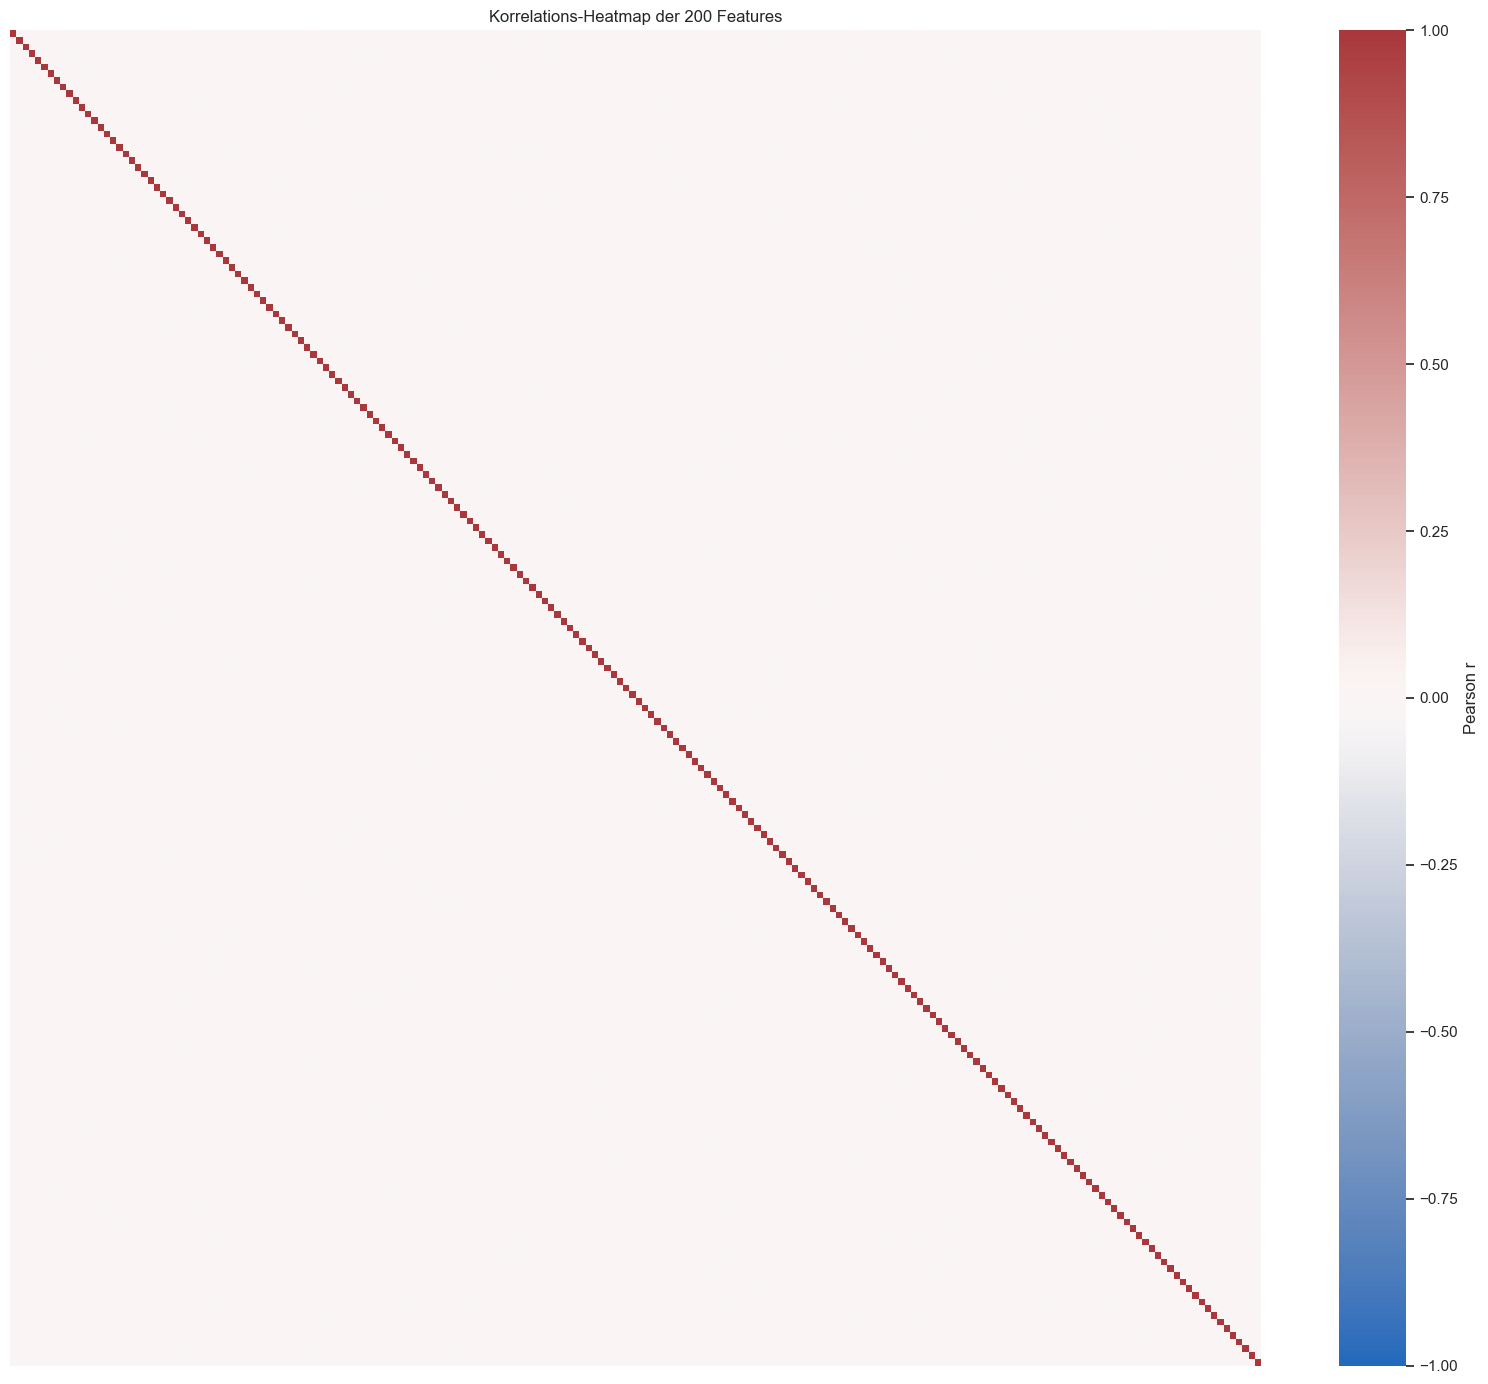

In [11]:
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(correlation_matrix.loc[feature_columns, feature_columns], cmap="vlag", center=0,
            vmin=-1, vmax=1, xticklabels=False, yticklabels=False, ax=ax, cbar_kws={"label": "Pearson r"})
ax.set_title("Korrelations-Heatmap der 200 Features")
fig.tight_layout()
fig.savefig(ASSET_PATH / "korrelations_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### 12.2 Boxplots und Verteilungen

Die Boxplots zeigen die normalisierten Werte je Feature. Da 200 Boxplots auf einer Achse sehr
dicht liegen, werden die Feature-Namen nur teilweise beschriftet. Zusätzlich werden die
Verteilung der Feature-Mittelwerte, eine Stichprobe aller Einzelwerte und Q-Q-Plots von vier
repräsentativen Features dargestellt. Q-Q-Plots gegen die Normalverteilung helfen dabei,
Abweichungen von einer Normalverteilung visuell zu erkennen.

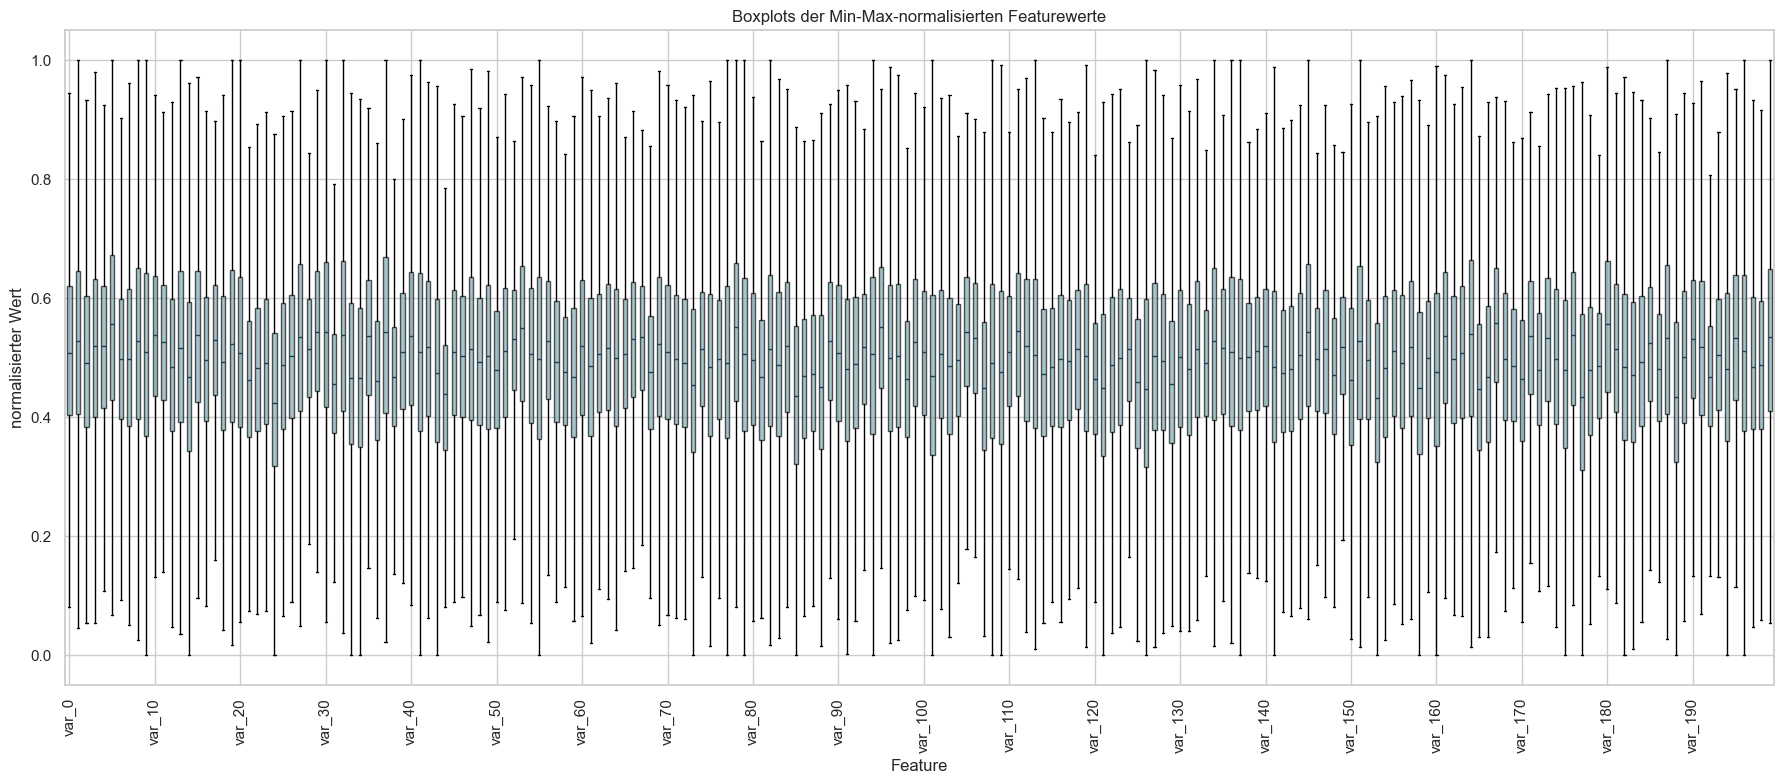

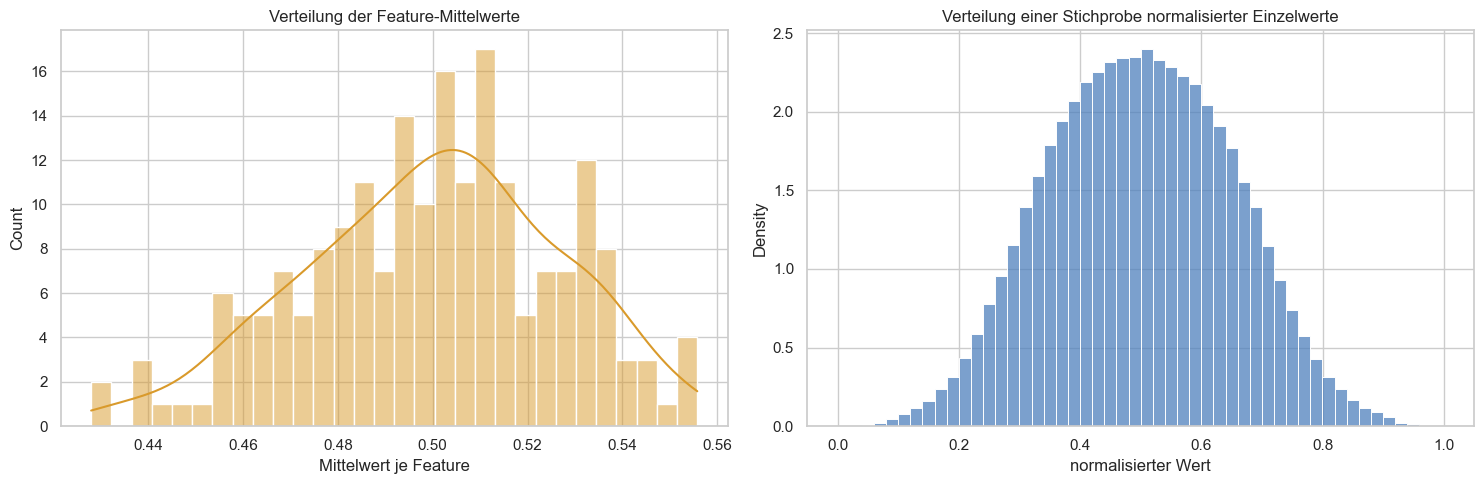

In [12]:
fig, ax = plt.subplots(figsize=(18, 8))
ax.boxplot(X_minmax.to_numpy(), showfliers=False, patch_artist=True,
            boxprops={"facecolor": "#76a5af", "alpha": 0.65},
            medianprops={"color": "#173f5f"})
ax.set_title("Boxplots der Min-Max-normalisierten Featurewerte")
ax.set_xlabel("Feature")
ax.set_ylabel("normalisierter Wert")
ax.set_xticks(range(1, len(feature_columns) + 1, 10), feature_columns[::10], rotation=90)
fig.tight_layout()
fig.savefig(ASSET_PATH / "boxplots_normalisierte_features.png", dpi=150, bbox_inches="tight")
plt.show()

rng = np.random.default_rng(42)
value_sample = X_minmax.to_numpy().ravel()[rng.choice(X_minmax.size, size=200000, replace=False)]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(X_minmax.mean(axis=0), bins=30, kde=True, ax=axes[0], color="#d99a2b")
axes[0].set_title("Verteilung der Feature-Mittelwerte")
axes[0].set_xlabel("Mittelwert je Feature")
sns.histplot(value_sample, bins=50, stat="density", ax=axes[1], color="#4f81bd")
axes[1].set_title("Verteilung einer Stichprobe normalisierter Einzelwerte")
axes[1].set_xlabel("normalisierter Wert")
fig.tight_layout()
fig.savefig(ASSET_PATH / "verteilungen_normalisierte_werte.png", dpi=150, bbox_inches="tight")
plt.show()

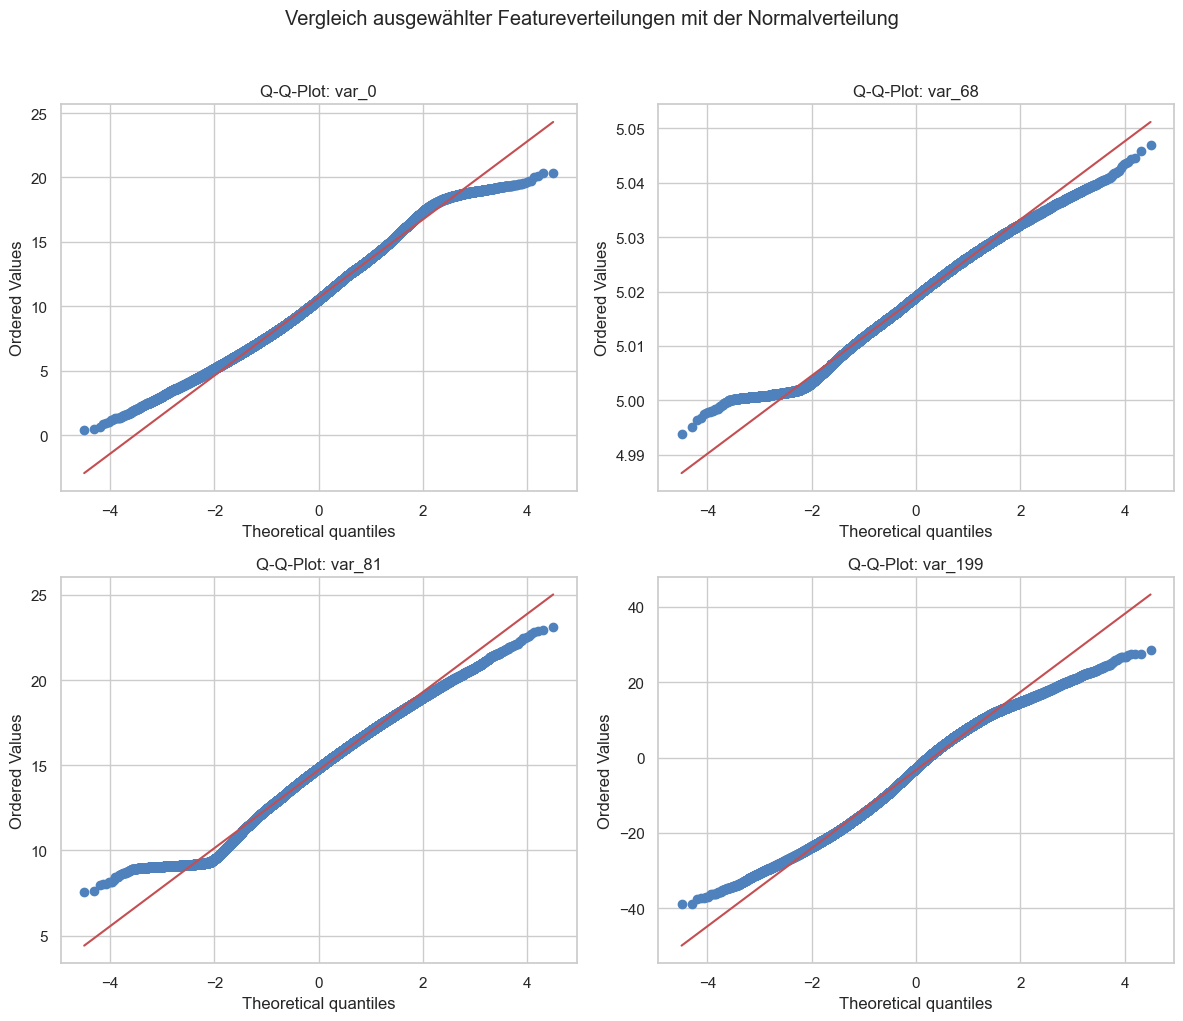

In [13]:
representative_features = ["var_0", "var_68", "var_81", "var_199"]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, feature in zip(axes.flat, representative_features):
    stats.probplot(X[feature], dist="norm", plot=ax)
    ax.set_title(f"Q-Q-Plot: {feature}")
    ax.get_lines()[0].set_markerfacecolor("#4f81bd")
    ax.get_lines()[0].set_markeredgecolor("#4f81bd")
fig.suptitle("Vergleich ausgewählter Featureverteilungen mit der Normalverteilung", y=1.02)
fig.tight_layout()
fig.savefig(ASSET_PATH / "qq_plots_representative_features.png", dpi=150, bbox_inches="tight")
plt.show()

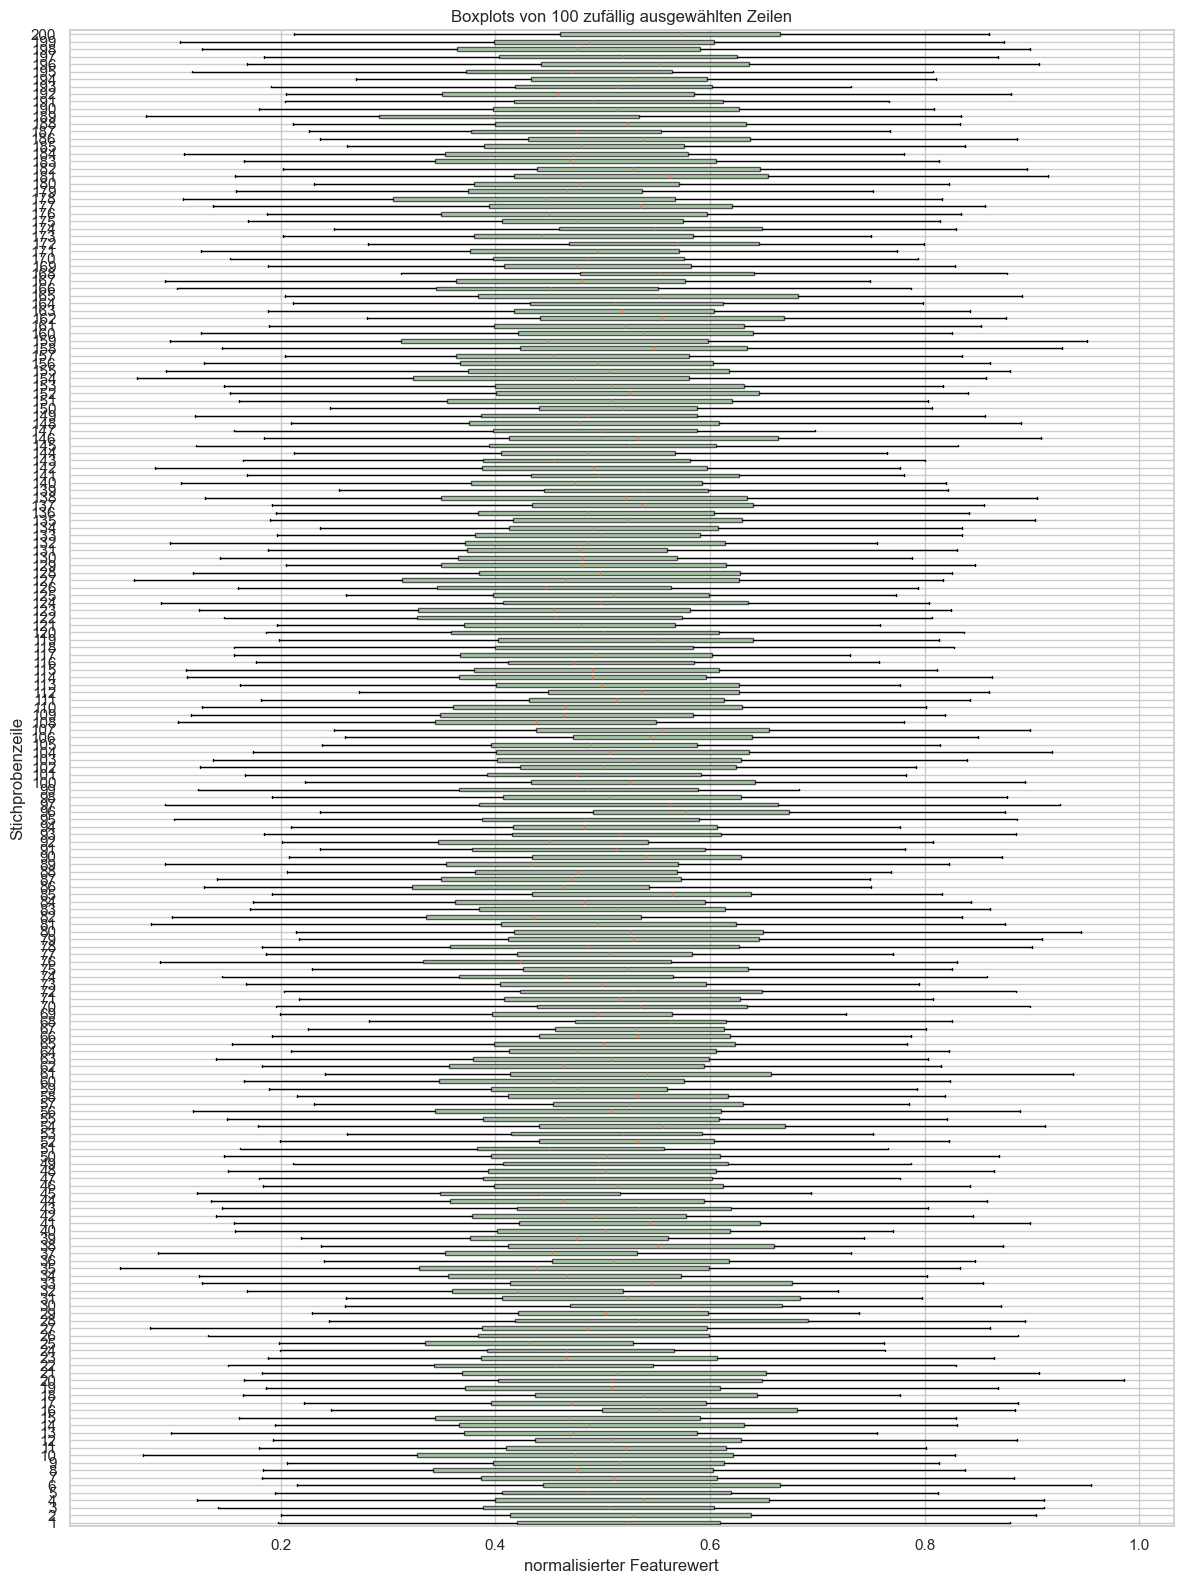

In [14]:
row_sample = X_minmax.sample(n=100, random_state=42)
fig, ax = plt.subplots(figsize=(12, 16))
ax.boxplot(row_sample.to_numpy(), vert=False, showfliers=False,
            patch_artist=True, boxprops={"facecolor": "#8fbc8f", "alpha": 0.65})
ax.set_title("Boxplots von 100 zufällig ausgewählten Zeilen")
ax.set_xlabel("normalisierter Featurewert")
ax.set_ylabel("Stichprobenzeile")
fig.tight_layout()
fig.savefig(ASSET_PATH / "boxplots_zeilen.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. PCA, t-SNE und Clustering

Für PCA wird die gesamte normalisierte Featurematrix verwendet. Für t-SNE und die
anschließenden Clusterverfahren wird eine reproduzierbare Stichprobe von 5.000 Zeilen genutzt,
weil t-SNE und DBSCAN auf 200.000 Zeilen sehr rechen- und speicherintensiv wären. Vor t-SNE
wird auf 50 PCA-Komponenten vorreduziert. `target` wird nur als Label gespeichert und zur
Nachinterpretation sowie zur farblichen Darstellung verwendet.

In [15]:
RANDOM_STATE = 42
EMBED_SAMPLE_SIZE = 5000
embed_indices = df.sample(n=EMBED_SAMPLE_SIZE, random_state=RANDOM_STATE).index
X_embed = X_minmax.loc[embed_indices]
y_embed = df.loc[embed_indices, TARGET].astype(int).to_numpy()

pca_2d_model = PCA(n_components=2, random_state=RANDOM_STATE)
pca_2d = pca_2d_model.fit_transform(X_minmax)
pca_sample_2d = pca_2d[embed_indices.to_numpy()]

pca_50_model = PCA(n_components=50, random_state=RANDOM_STATE)
X_embed_pca50 = pca_50_model.fit_transform(X_embed)
tsne_2d_model = TSNE(n_components=2, perplexity=30, init="pca", learning_rate="auto",
                    max_iter=750, random_state=RANDOM_STATE, n_jobs=-1)
tsne_2d = tsne_2d_model.fit_transform(X_embed_pca50)

print("PCA-2D gesamte Matrix:", pca_2d.shape)
print("PCA erklärte Varianz (2 Komponenten):", pca_2d_model.explained_variance_ratio_.round(6))
print("t-SNE-Matrix:", tsne_2d.shape)
print("Für Embeddings/Cluster verwendete Stichprobe:", EMBED_SAMPLE_SIZE)

PCA-2D gesamte Matrix: (200000, 2)
PCA erklärte Varianz (2 Komponenten): [0.007503 0.00686 ]
t-SNE-Matrix: (5000, 2)
Für Embeddings/Cluster verwendete Stichprobe: 5000


In [16]:
def cluster_embedding(embedding, name, eps=0.5):
    scaled_embedding = StandardScaler().fit_transform(embedding)
    kmeans_labels = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10).fit_predict(scaled_embedding)
    dbscan_labels = DBSCAN(eps=eps, min_samples=10, n_jobs=-1).fit_predict(scaled_embedding)
    print(f"{name}: K-Means Clustergrößen", np.bincount(kmeans_labels))
    unique_dbscan, counts_dbscan = np.unique(dbscan_labels, return_counts=True)
    print(f"{name}: DBSCAN Clustergrößen", dict(zip(unique_dbscan.tolist(), counts_dbscan.tolist())))
    print(f"{name}: K-Means ARI/NMI zu target", round(adjusted_rand_score(y_embed, kmeans_labels), 4), round(normalized_mutual_info_score(y_embed, kmeans_labels), 4))
    print(f"{name}: DBSCAN ARI/NMI zu target", round(adjusted_rand_score(y_embed, dbscan_labels), 4), round(normalized_mutual_info_score(y_embed, dbscan_labels), 4))
    return kmeans_labels, dbscan_labels

pca_kmeans, pca_dbscan = cluster_embedding(pca_sample_2d, "PCA", eps=0.5)
tsne_kmeans, tsne_dbscan = cluster_embedding(tsne_2d, "t-SNE", eps=0.5)

PCA: K-Means Clustergrößen [2726 2274]
PCA: DBSCAN Clustergrößen {-1: 1, 0: 4999}
PCA: K-Means ARI/NMI zu target -0.0016 0.0004
PCA: DBSCAN ARI/NMI zu target 0.0032 0.0028


t-SNE: K-Means Clustergrößen [2479 2521]
t-SNE: DBSCAN Clustergrößen {0: 5000}
t-SNE: K-Means ARI/NMI zu target 0.0008 0.0015
t-SNE: DBSCAN ARI/NMI zu target 0.0 0.0


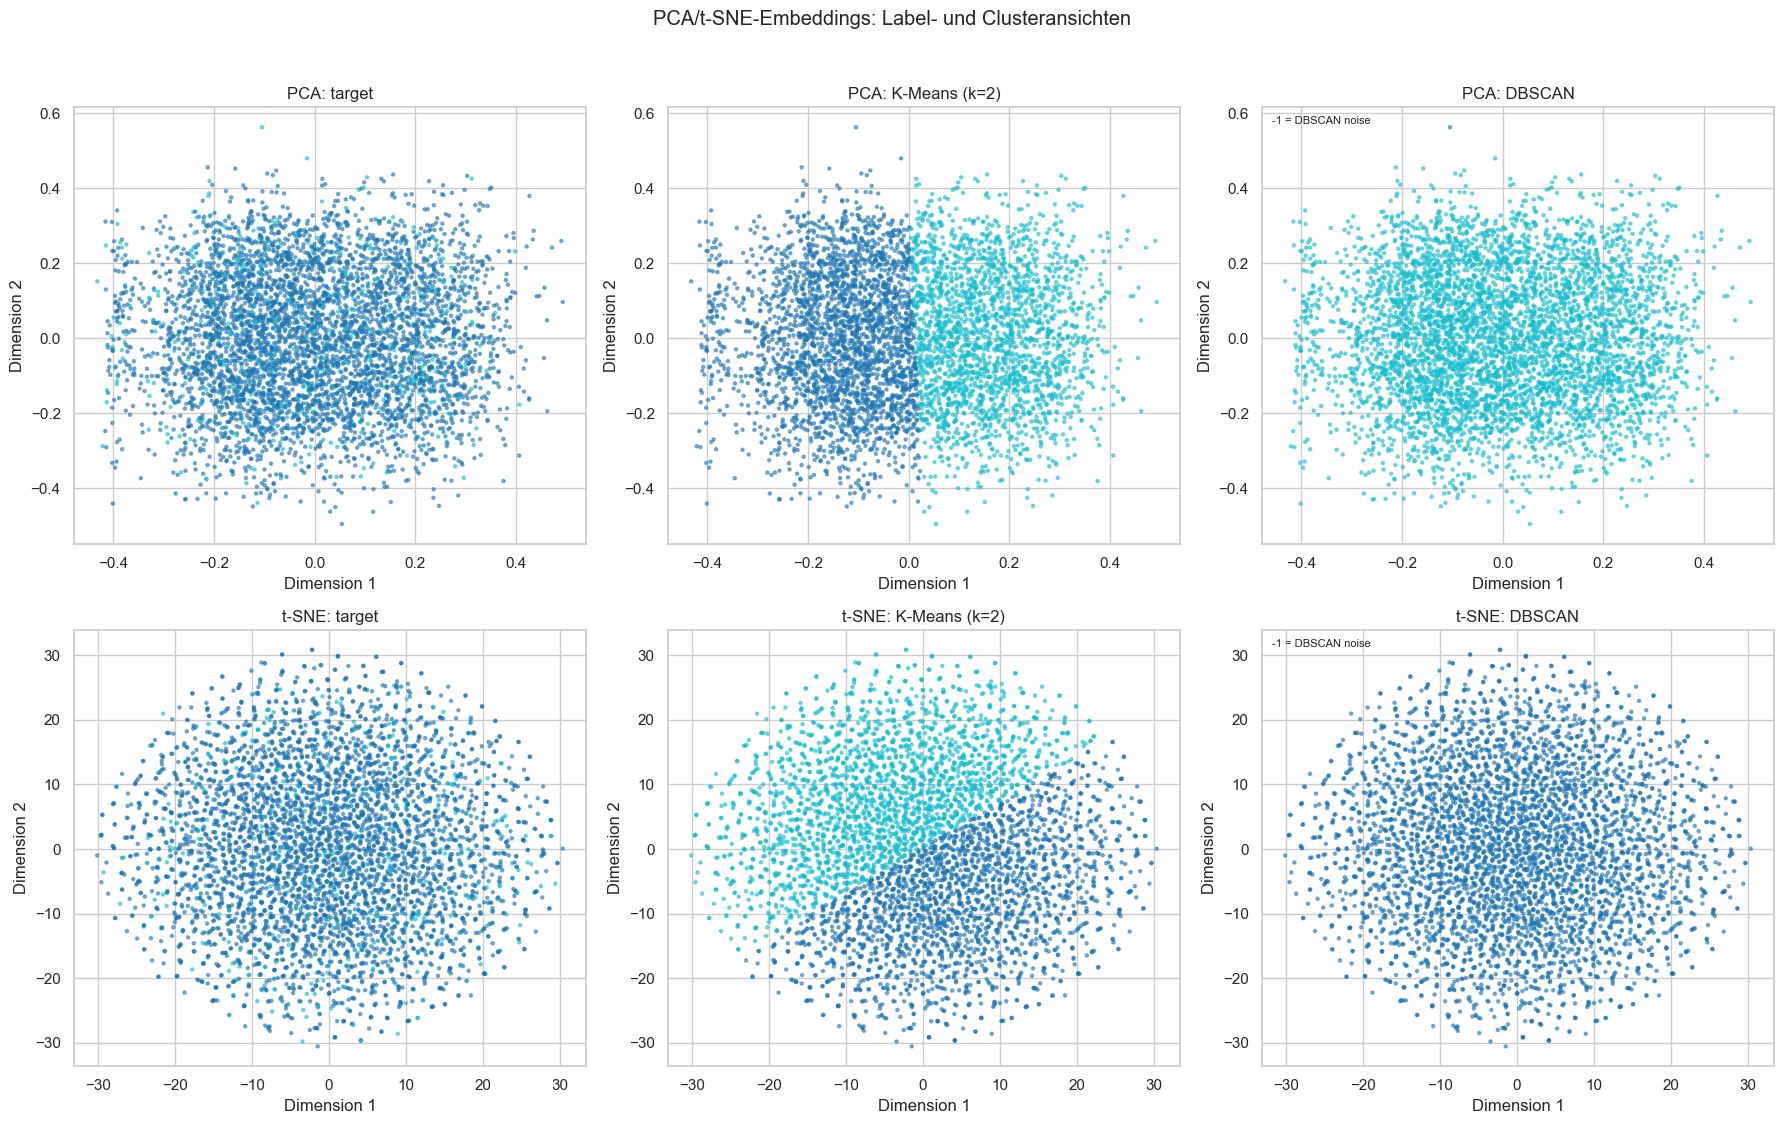

In [17]:
plot_specs = [
    (pca_sample_2d, y_embed, "PCA: target", "pca_target.png", "target"),
    (pca_sample_2d, pca_kmeans, "PCA: K-Means (k=2)", "pca_kmeans.png", "cluster"),
    (pca_sample_2d, pca_dbscan, "PCA: DBSCAN", "pca_dbscan.png", "cluster"),
    (tsne_2d, y_embed, "t-SNE: target", "tsne_target.png", "target"),
    (tsne_2d, tsne_kmeans, "t-SNE: K-Means (k=2)", "tsne_kmeans.png", "cluster"),
    (tsne_2d, tsne_dbscan, "t-SNE: DBSCAN", "tsne_dbscan.png", "cluster"),
]
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for ax, (embedding, labels, title, filename, label_type) in zip(axes.flat, plot_specs):
    scatter = ax.scatter(embedding[:, 0], embedding[:, 1], c=labels, s=5, alpha=0.55, cmap="tab10")
    ax.set_title(title)
    ax.set_xlabel("Dimension 1")
    ax.set_ylabel("Dimension 2")
    if label_type == "cluster":
        ax.text(0.02, 0.98, "-1 = DBSCAN noise" if "DBSCAN" in title else "", transform=ax.transAxes, va="top", fontsize=8)
fig.suptitle("PCA/t-SNE-Embeddings: Label- und Clusteransichten", y=1.02)
fig.tight_layout()
fig.savefig(ASSET_PATH / "pca_tsne_clustering_overview.png", dpi=150, bbox_inches="tight")
plt.show()

## 14. Einordnung der Clusteranalyse

Die Clusterlabels sind unüberwacht entstanden. ARI und NMI vergleichen sie nachträglich mit
`target`, sind aber keine Trainingsmetriken. Besonders bei t-SNE darf eine sichtbare Trennung
nicht automatisch als fachlich belastbare Struktur interpretiert werden, da t-SNE lokale
Nachbarschaften betont und seine globale Geometrie verzerren kann. DBSCAN-Cluster hängen zudem
stark von `eps` und `min_samples` ab; diese Parameter werden in einem späteren Schritt begründet
und systematisch sensitivitätsgeprüft.